# Vine-copula forests with MCS-based survivor selection

This notebook is the companion to `08_sklearn_estimators.ipynb`. The
single-vine estimators in that notebook commit to one (greedily chosen)
vine structure. In real datasets the greedy choice is often suboptimal,
and many alternative structures are statistically indistinguishable from
each other — so it makes sense to *search* over structures and *ensemble*
the survivors.

`VineForestDensity` and `VineForestRegressor` implement exactly that:

1. Hold out a fraction of the training data for survivor selection.
2. Sample `n_vines` candidate structures (uniform R-vines by default;
   Wilson-weighted random walks as an option).
3. Fit each on a bootstrap resample of the training portion, score on
   the held-out set.
4. Keep only the structures inside a model confidence set (MCS) computed
   via the dual-split DA test adapted from Kim & Ramdas (2025).
5. Refit survivors on the full training data; average predictions.

Same California Housing subsample as the single-vine notebook, trimmed
to 1000 rows to keep the forest fit fast.

In [1]:
import pytest

pytest.importorskip("sklearn")
pytest.importorskip("pandas")
pytest.importorskip("joblib")
pytest.importorskip("scipy")

import time

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from pyvinecopulib.sklearn import (
  VineDensity,
  VineForestDensity,
  VineForestRegressor,
  VineRegressor,
)

rng = np.random.default_rng(0)

In [2]:
X_full, y_full = fetch_california_housing(return_X_y=True)
idx = rng.choice(X_full.shape[0], size=1000, replace=False)
X, y = X_full[idx], y_full[idx]
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.25, random_state=42
)
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
print(f"train: {X_train.shape}, test: {X_test.shape}")

train: (750, 8), test: (250, 8)


## Regression: single vine vs. forest

We fit:

- `VineRegressor` (single Dissmann-structure baseline).
- `VineForestRegressor` with `best_only=True` (keep just the validation
  winner — `RS-B` in Vatter & Nagler 2026).
- `VineForestRegressor` with `best_only=False` (keep the whole MCS and
  average predictions — `RS-E` in Vatter & Nagler 2026).

To keep the notebook fast we only ask for the median quantile, so each
`predict` call evaluates one statistic per surviving tree.

In [3]:
base_params = {"mean": True, "quantiles": [0.5]}

t0 = time.time()
single = VineRegressor(**base_params).fit(X_train, y_train)
print(f"VineRegressor (single): fit {time.time() - t0:.1f}s")

t0 = time.time()
forest_b = VineForestRegressor(
  base_params=base_params,
  n_vines=10,
  n_jobs=1,
  val_fraction=0.25,
  best_only=True,
  seed=0,
).fit(X_train, y_train)
print(
  f"VineForestRegressor (best_only): fit {time.time() - t0:.1f}s "
  f"-> {len(forest_b._estimators)} survivor(s)"
)

t0 = time.time()
forest_e = VineForestRegressor(
  base_params=base_params,
  n_vines=10,
  n_jobs=1,
  val_fraction=0.25,
  best_only=False,
  seed=0,
).fit(X_train, y_train)
print(
  f"VineForestRegressor (ensemble): fit {time.time() - t0:.1f}s "
  f"-> {len(forest_e._estimators)} survivor(s) "
  f"(selection rate {forest_e._selection_rate:.0%}, "
  f"Dissmann in MCS: {forest_e._default_selected})"
)

VineRegressor (single): fit 0.3s


VineForestRegressor (best_only): fit 7.9s -> 1 survivor(s)


VineForestRegressor (ensemble): fit 17.5s -> 11 survivor(s) (selection rate 100%, Dissmann in MCS: True)


Compare RMSE on the conditional mean.

In [4]:
def rmse(est):
  return root_mean_squared_error(y_test, est.predict(X_test)[:, 0])


print(f"{'model':<32} {'RMSE':>6}")
for name, est in [
  ("VineRegressor (Dissmann)", single),
  ("VineForestRegressor (best_only)", forest_b),
  ("VineForestRegressor (ensemble)", forest_e),
]:
  print(f"{name:<32} {rmse(est):>6.3f}")

model                              RMSE


VineRegressor (Dissmann)          0.701


VineForestRegressor (best_only)   0.703


VineForestRegressor (ensemble)    0.677


`_estimators_logliks` records the held-out validation log-likelihood
for each surviving structure (averaged across rows). The default
Dissmann baseline is appended last when `add_dissmann=True`, so a quick
bar plot tells you whether the random-search structures actually beat
it.

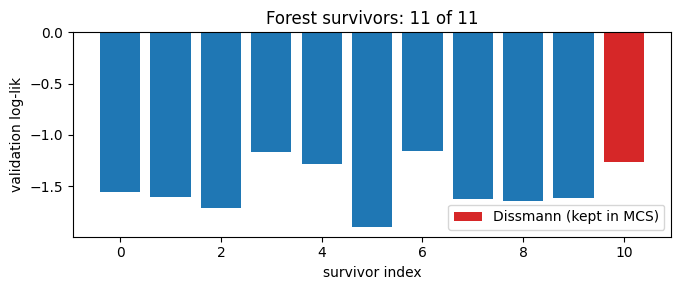

In [5]:
fig, ax = plt.subplots(figsize=(7, 3))
logliks = forest_e._estimators_logliks.ravel()
ax.bar(range(len(logliks)), logliks)
if forest_e._default_selected:
  ax.bar(
    [len(logliks) - 1],
    [logliks[-1]],
    color="C3",
    label="Dissmann (kept in MCS)",
  )
  ax.legend()
ax.set_xlabel("survivor index")
ax.set_ylabel("validation log-lik")
ax.set_title(f"Forest survivors: {len(logliks)} of {forest_e.n_vines + 1}")
plt.tight_layout()

## Wilson-weighted local sampling

`vines_sampling="local"` draws each tree from
$P(T) \propto \prod_{(j,k) \in T} |\hat\tau_{j,k}|$ via Wilson's
loop-erased random walk (the Dissmann maximum spanning tree is the mode
of this distribution). It typically produces structures closer to the
Dissmann baseline than uniform sampling.

In [6]:
t0 = time.time()
forest_local = VineForestRegressor(
  base_params=base_params,
  n_vines=10,
  n_jobs=1,
  val_fraction=0.25,
  vines_sampling="local",
  seed=0,
).fit(X_train, y_train)
print(
  f"local sampling: fit {time.time() - t0:.1f}s -> "
  f"{len(forest_local._estimators)} survivor(s), "
  f"RMSE={rmse(forest_local):.3f}"
)

local sampling: fit 26.6s -> 10 survivor(s), RMSE=0.658


## Density forest

`VineForestDensity` mirrors the regressor: random search +
MCS-based survivor selection, then the per-sample density is the simple
average over survivors. `sample(n)` draws from the mixture distribution
in one call per surviving estimator (efficient even for large `n`);
`cdf` averages each survivor's quasi-MC CDF estimate.

In [7]:
t0 = time.time()
dens_forest = VineForestDensity(
  n_vines=6,
  n_jobs=1,
  val_fraction=0.25,
  seed=0,
).fit(X_train)
print(
  f"VineForestDensity fit: {time.time() - t0:.1f}s -> "
  f"{len(dens_forest._estimators)} survivor(s)"
)

t0 = time.time()
single_dens = VineDensity().fit(X_train)
nll_single = -single_dens.score_samples(X_test).mean()
nll_forest = -dens_forest.score_samples(X_test).mean()
print(f"NLL (single VineDensity):       {nll_single:.3f}")
print(
  f"NLL (VineForestDensity, M={len(dens_forest._estimators)}): {nll_forest:.3f}"
)

VineForestDensity fit: 3.0s -> 3 survivor(s)


NLL (single VineDensity):       6.513
NLL (VineForestDensity, M=3): 6.255


Quick sanity check on the sampler: draw 1000 synthetic rows from the
forest and compare the marginal of the first feature to the training
distribution.

sample shape: (1000, 8)


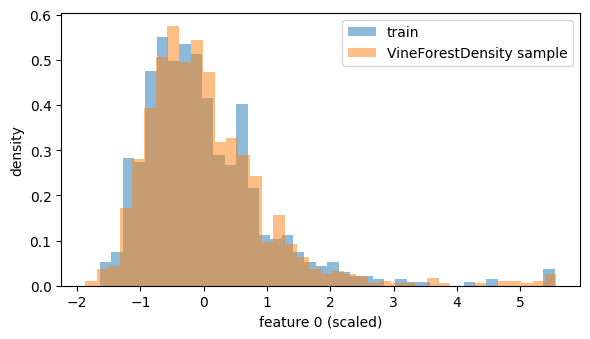

In [8]:
synth = dens_forest.sample(n_samples=1000)
print(f"sample shape: {synth.shape}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(X_train[:, 0], bins=40, alpha=0.5, density=True, label="train")
ax.hist(
  synth[:, 0],
  bins=40,
  alpha=0.5,
  density=True,
  label="VineForestDensity sample",
)
ax.set_xlabel("feature 0 (scaled)")
ax.set_ylabel("density")
ax.legend()
plt.tight_layout()

## What's next

- To get the conditional density `f(y | x)` from a forest regressor,
  reach for the private `VineForestRegressor._loglik_estimator(est, X, y)`
  directly — it implements the three-term identity from Nagler & Vatter
  (2024). A future PR may surface this as a public method.
- The MCS itself lives at `pyvinecopulib.sklearn._mcs`. It is private
  for now; promote to a public utility if you need to apply it to
  model-selection problems outside vine copulas.